Source Data :https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor

# **1. Import Library**

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# **2. Mount Google Drive**

In [69]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **3. Load Dataset CSV**

In [70]:
file_path = "/content/drive/MyDrive/Computer Vision/Tugas2/Dataset/Brain Tumor.csv"

df = pd.read_csv(file_path)

# lihat data
df.head()

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


# **4. Cek Dataset**

In [71]:
print("Jumlah data:", df.shape)
print(df.info())
print(df.describe())

Jumlah data: (3762, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Image               3762 non-null   object 
 1   Class               3762 non-null   int64  
 2   Mean                3762 non-null   float64
 3   Variance            3762 non-null   float64
 4   Standard Deviation  3762 non-null   float64
 5   Entropy             3762 non-null   float64
 6   Skewness            3762 non-null   float64
 7   Kurtosis            3762 non-null   float64
 8   Contrast            3762 non-null   float64
 9   Energy              3762 non-null   float64
 10  ASM                 3762 non-null   float64
 11  Homogeneity         3762 non-null   float64
 12  Dissimilarity       3762 non-null   float64
 13  Correlation         3762 non-null   float64
 14  Coarseness          3762 non-null   float64
dtypes: float64(13), int64(1), objec

# **5. Pre-Processing**

In [72]:
# Pisahkan fitur & label
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Ambil hanya data numerik
X = X.select_dtypes(include=[np.number])

# Encode label kalau bukan angka
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# **6. Split Data**

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3009, 13)
Test: (753, 13)


# **7. Normalisasi Data**

In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **8. Training Model KNN**

In [75]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

# Model K-Nearest Neighbor (KNN)

KNN adalah algoritma klasifikasi yang bekerja dengan mencari K tetangga terdekat dari suatu data berdasarkan jarak.

Data akan diklasifikasikan berdasarkan mayoritas kelas dari tetangga terdekat tersebut.

Pada penelitian ini digunakan nilai K = 5.

# **9. Prediksi**

In [76]:
y_pred = knn.predict(X_test)

# **10. Evaluasi Model**

In [77]:
# EVALUASI MODEL

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model KNN: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix (nilai)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n")
print(cm)

Akurasi Model KNN: 0.8380

Classification Report:

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       634
           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         2
          17       0.00      0.00      0.00         1
          18       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         1
          21       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         1
          25       0.00      0.00      0.00         1
          26       0.00      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Evaluasi Model

Model dievaluasi menggunakan beberapa metrik, yaitu:

- Accuracy: Mengukur tingkat ketepatan model
- Classification Report: Menampilkan precision, recall, dan f1-score
- Confusion Matrix: Menunjukkan perbandingan antara hasil prediksi dan data aktual

Evaluasi ini digunakan untuk mengetahui seberapa baik performa model KNN dalam mengklasifikasikan data.

# **11. Confusion Matrix (Visual)**

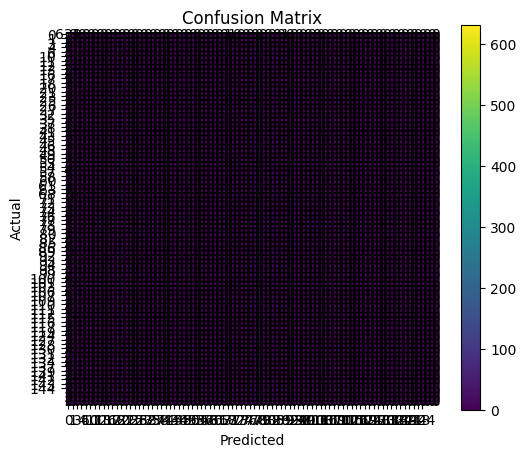

In [78]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = np.unique(y_test)

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Confusion Matrix (Visual)

Confusion Matrix digunakan untuk mengevaluasi performa model klasifikasi dengan membandingkan hasil prediksi dengan data aktual.

Visualisasi confusion matrix membantu dalam memahami jumlah prediksi yang benar dan salah secara lebih intuitif.

Setiap nilai dalam matriks menunjukkan:
- True Positive (TP): Prediksi benar untuk kelas positif
- True Negative (TN): Prediksi benar untuk kelas negatif
- False Positive (FP): Prediksi salah (positif padahal negatif)
- False Negative (FN): Prediksi salah (negatif padahal positif)

Dengan melihat confusion matrix, dapat diketahui seberapa baik model dalam mengklasifikasikan data.

# **11. Visualisasi (Perbandingan Hasil Prediksi)**

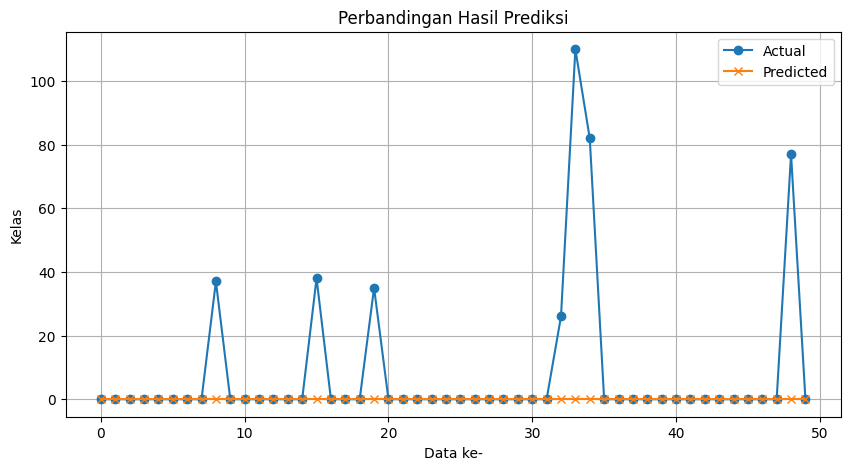

In [79]:
plt.figure(figsize=(10,5))
plt.plot(y_test[:50], marker='o', label="Actual")
plt.plot(y_pred[:50], marker='x', label="Predicted")
plt.legend()
plt.title("Perbandingan Hasil Prediksi")
plt.xlabel("Data ke-")
plt.ylabel("Kelas")
plt.grid()
plt.show()

# Visualisasi Hasil

Visualisasi dilakukan untuk melihat perbandingan antara nilai aktual dan hasil prediksi.

Grafik ini membantu dalam memahami performa model secara lebih intuitif.